# Noches completas

Hasta ahora nos enfocamos en la variabilidad de los perfiles, e inclusive si predominancia en las distintas estaciones.
Ahora vamos a tratar de explorar la variabilidad del comportamiento nocturno.

Las variables nocturnas, para cada noche, que vamos a explorar, son las siguientes, los primeros ya los tenemos del Nb 6:

| Variable                       | Significado          |
| ------------------------------ | -------------------- |
| cluster dominante              | estado principal     |
| porcentaje dominante           | qué tan homogénea es |
| entropía                       | heterogeneidad       |
| cantidad de clusters presentes | complejidad          |
| número de transiciones         | dinámica             |
| persistencia máxima            | estabilidad          |
| perfiles totales               | duración/calidad     |



In [6]:
# Cargamos librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Vamos a cargar los datasets que vienen del Nb 6

df= pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\dataset_C_clusterizado_k2_k7_mes_estacion.csv", 
                 encoding= "ISO-8859-1")

resumen_noches = pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\resumen_nocturno_clusters.csv",
    index_col=0)

df["fecha"] = pd.to_datetime(df["fecha"])
resumen_noches.index = pd.to_datetime(resumen_noches.index)

In [9]:
# Vamos a ver la cantidad de transiciones por noche
# y vamos a normalizarlas, no es lo mismo, 2 transiciones en 5 perfiles, que 2 en 50 perfiles

cluster_col = "cluster_4"

def contar_transiciones(grupo):

    secuencia = (
        grupo.sort_values("time")[cluster_col]
        .values)

    return np.sum(
        secuencia[1:] != secuencia[:-1])

transiciones = (
    df.groupby("fecha")[["time", cluster_col]]
      .apply(contar_transiciones))

resumen_noches["transiciones"] = transiciones

n_perfiles = (df.groupby("fecha").size())

resumen_noches["n_perfiles"] = n_perfiles

resumen_noches["transiciones_norm"] = (
    resumen_noches["transiciones"]
    / (resumen_noches["n_perfiles"] - 1))

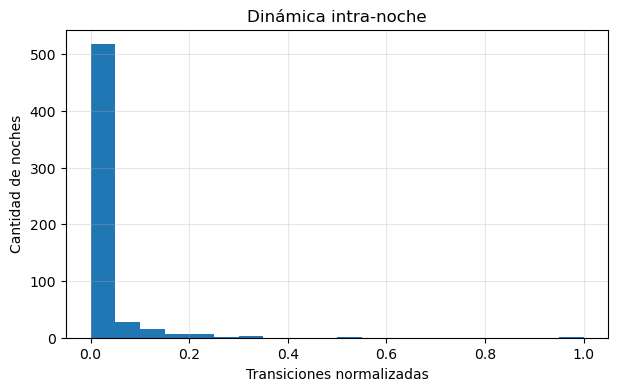

In [10]:
# Vamos a graficar

plt.figure(figsize=(7,4))

plt.hist(
    resumen_noches["transiciones_norm"],
    bins=20)

plt.xlabel("Transiciones normalizadas")
plt.ylabel("Cantidad de noches")

plt.title("Dinámica intra-noche")

plt.grid(alpha=0.3)

plt.show()

In [12]:
# Lo que nos dice este gráfico es que la mayoría de las noches tienen pocos cambios de estado, aunque hay casos extremos!
#Vamos a listar los 10 ejemplos más estables y los 10 más inestables

resumen_noches.sort_values(
    "transiciones_norm"
).head(10)

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia,transiciones,n_perfiles,transiciones_norm
fecha,,,,,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,8,0.0
2024-01-15,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,8,0.0
2024-01-12,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,17,0.0
2024-01-11,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,16,0.0
2024-01-10,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,5,0.0
2024-01-09,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,15,0.0
2024-01-06,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,11,0.0
2024-01-04,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,8,0.0
2024-01-03,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11,0,9,0.0


In [14]:
# Vamos a ver noches completamente estables
# En el listado aparecen los primeros ejemplos sólo de C2, pero pueden haber otros
# noches completamente estables
noches_estables = resumen_noches[
    resumen_noches["transiciones"] == 0
]

# contar por cluster dominante
conteo_estables = (
    noches_estables["cluster_dominante"]
    .value_counts()
    .sort_index())

print(conteo_estables)

porcentajes_estables = (
    conteo_estables
    / conteo_estables.sum()
    * 100)

print(porcentajes_estables)

tabla_estables = (
    noches_estables.groupby("cluster_dominante")
    .agg({
        "max_pct": ["mean", "min", "max"],
        "n_perfiles": ["mean", "count"]}))

tabla_estables



cluster_dominante
C0     43
C1    100
C2    276
C3     85
Name: count, dtype: int64
cluster_dominante
C0     8.531746
C1    19.841270
C2    54.761905
C3    16.865079
Name: count, dtype: float64


max_pct           n_perfiles      
                     mean  min  max       mean count
cluster_dominante                                   
C0                    1.0  1.0  1.0  21.534884    43
C1                    1.0  1.0  1.0  19.960000   100
C2                    1.0  1.0  1.0  12.405797   276
C3                    1.0  1.0  1.0  21.717647    85

In [15]:
# total de noches por cluster dominante
total_por_cluster = (
    resumen_noches["cluster_dominante"]
    .value_counts()
    .sort_index()
)

# noches estables por cluster
estables_por_cluster = (
    resumen_noches[
        resumen_noches["transiciones"] == 0
    ]["cluster_dominante"]
    .value_counts()
    .sort_index()
)

# porcentaje
pct_estables = (
    estables_por_cluster
    / total_por_cluster
    * 100
)

tabla_estabilidad = pd.DataFrame({
    "total_noches": total_por_cluster,
    "noches_estables": estables_por_cluster,
    "pct_estables": pct_estables
})

tabla_estabilidad

,total_noches,noches_estables,pct_estables
cluster_dominante,,,
C0,72,43,59.722222
C1,122,100,81.967213
C2,293,276,94.197952
C3,110,85,77.272727


### Con estos resultados vemos que la atmósfera suele permanecer dentro de un mismo régimen durante la noche
### Incluso en el caso con menor porcentaje, C0 es aproximadamente del 60%

En orden de estabilidad podemos ver C2, C1, C3 Y C0.
Con estas altas proporciones podemos decir que cada uno es representativo.


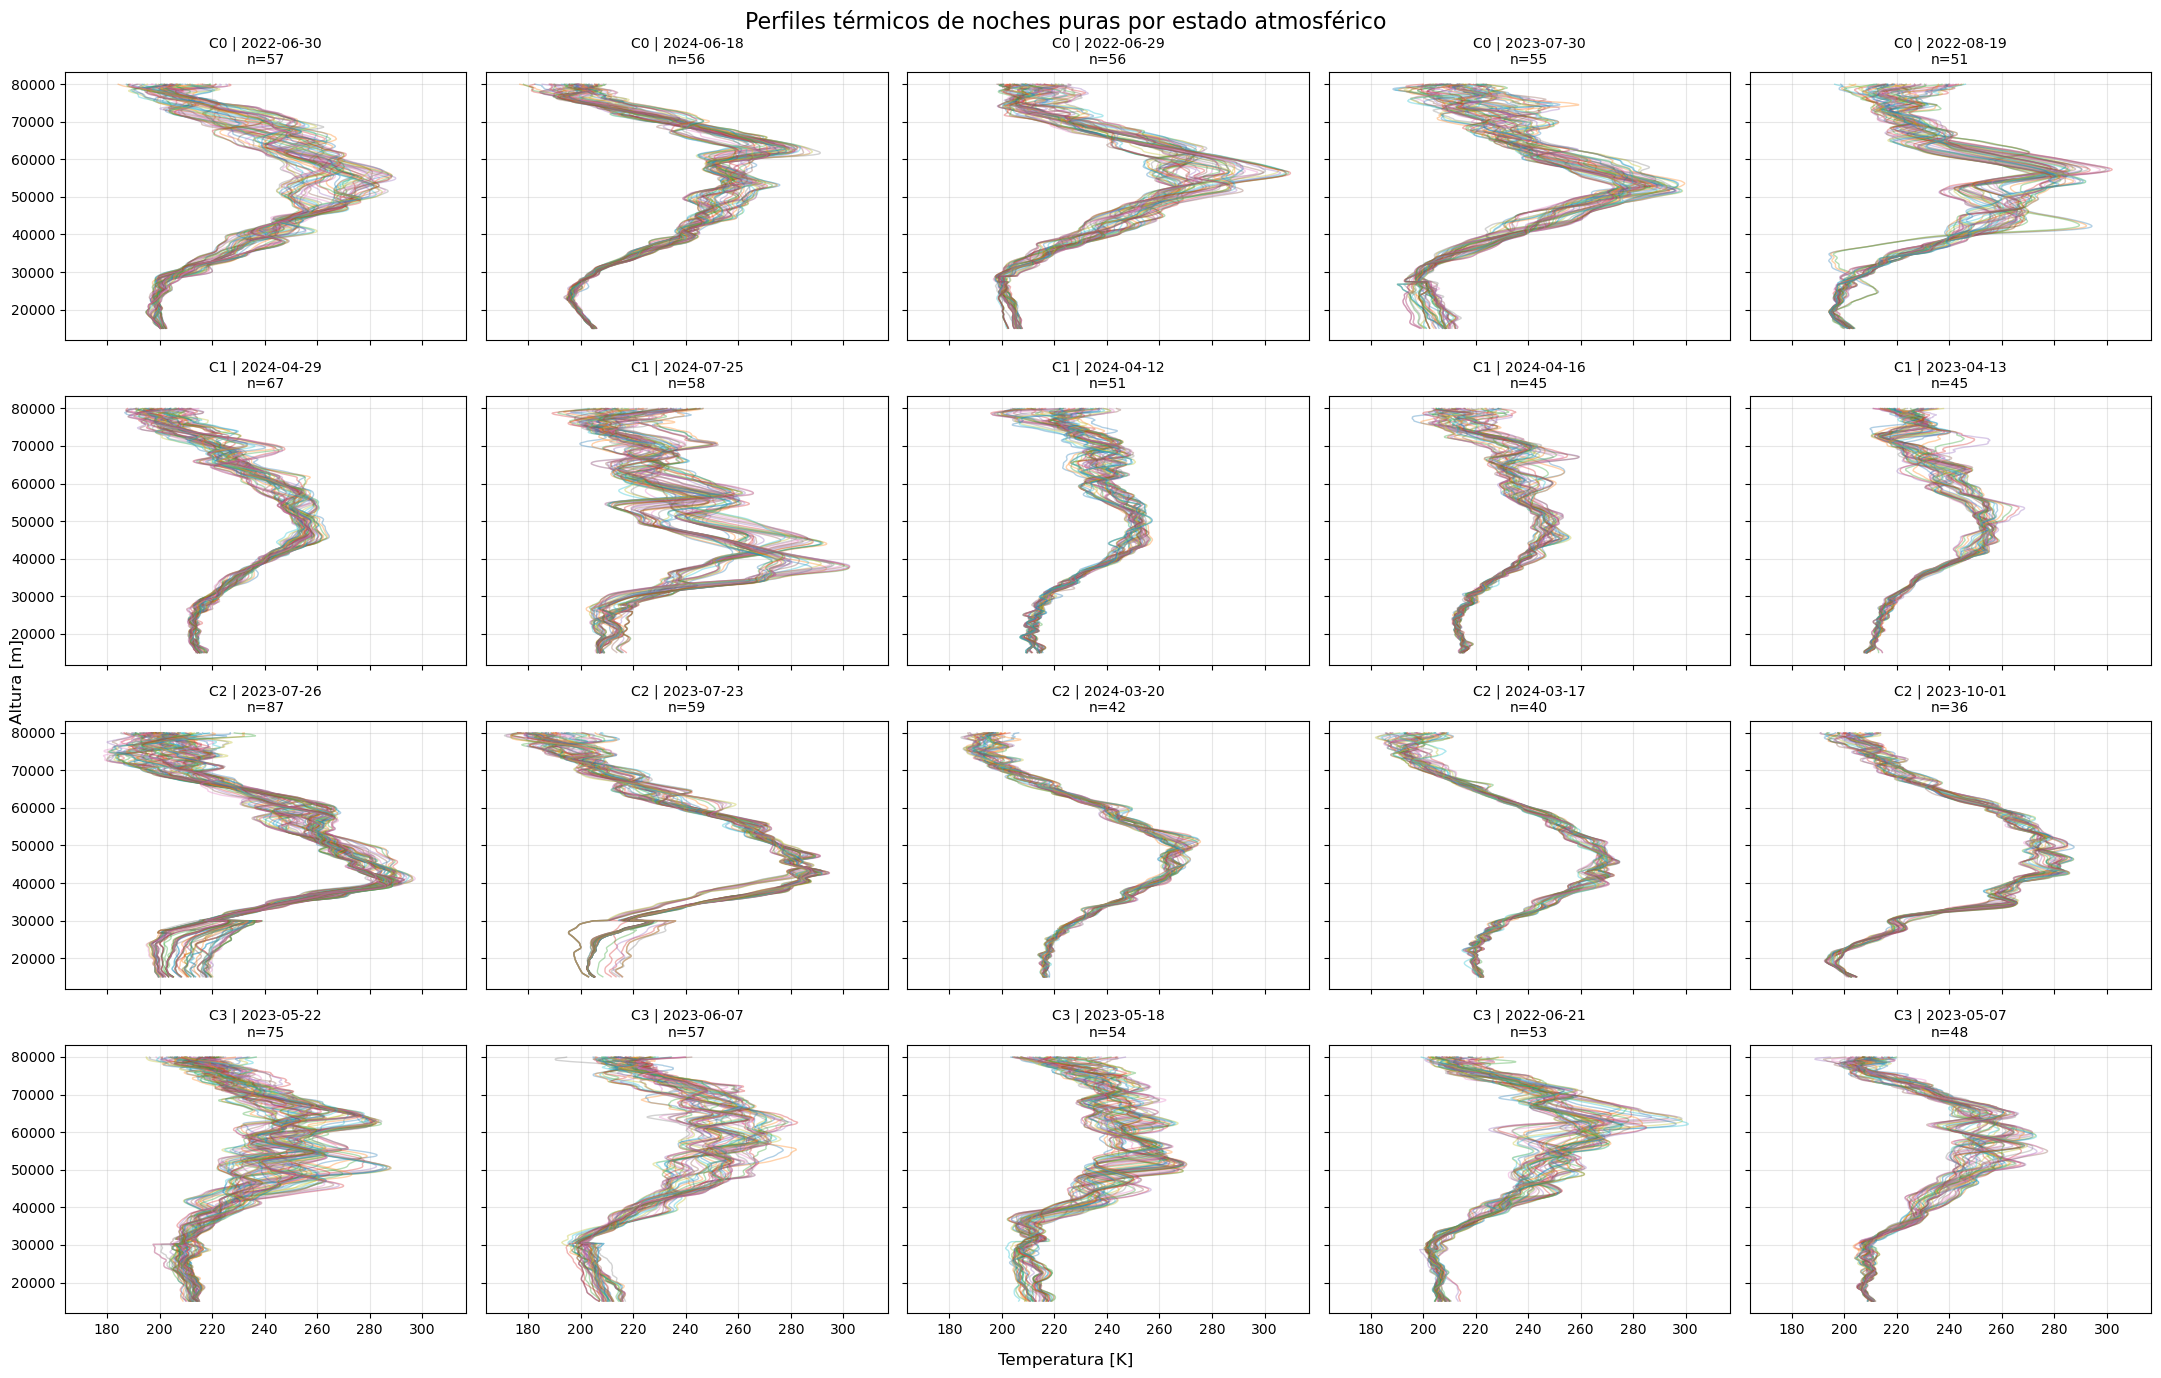

In [17]:
# Vamos a ver ejemplos de cada noche pura
import matplotlib.pyplot as plt

cluster_col = "cluster_4"

df["fecha"] = pd.to_datetime(df["fecha"])
resumen_noches.index = pd.to_datetime(resumen_noches.index)

# Columnas de alturas
cols_alturas = [
    col for col in df.columns
    if str(col).isdigit()
]

alturas = [int(col) for col in cols_alturas]

# Noches puras
noches_puras = resumen_noches[
    (resumen_noches["transiciones"] == 0) &
    (resumen_noches["max_pct"] == 1)
].copy()

# Elegimos 5 noches puras por cluster, priorizando noches con más perfiles
noches_puras_muestra = (
    noches_puras
    .sort_values("n_perfiles", ascending=False)
    .groupby("cluster_dominante")
    .head(5)
)

clusters = ["C0", "C1", "C2", "C3"]

fig, axes = plt.subplots(
    nrows=4,
    ncols=5,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)

for i, cluster in enumerate(clusters):
    
    fechas_cluster = (
        noches_puras_muestra[
            noches_puras_muestra["cluster_dominante"] == cluster
        ]
        .index
        .tolist()
    )
    
    for j in range(5):
        
        ax = axes[i, j]
        
        if j < len(fechas_cluster):
            
            fecha = fechas_cluster[j]
            
            noche = (
                df[df["fecha"] == fecha]
                .sort_values("time")
            )
            
            for _, perfil in noche.iterrows():
                ax.plot(
                    perfil[cols_alturas].values,
                    alturas,
                    alpha=0.35,
                    linewidth=1
                )
            
            ax.set_title(
                f"{cluster} | {fecha.date()}\n"
                f"n={len(noche)}",
                fontsize=10
            )
            
            ax.grid(alpha=0.3)
        
        else:
            ax.axis("off")

fig.suptitle(
    "Perfiles térmicos de noches puras por estado atmosférico",
    fontsize=16
)

fig.supxlabel("Temperatura [K]")
fig.supylabel("Altura [m]")

plt.tight_layout()
plt.show()

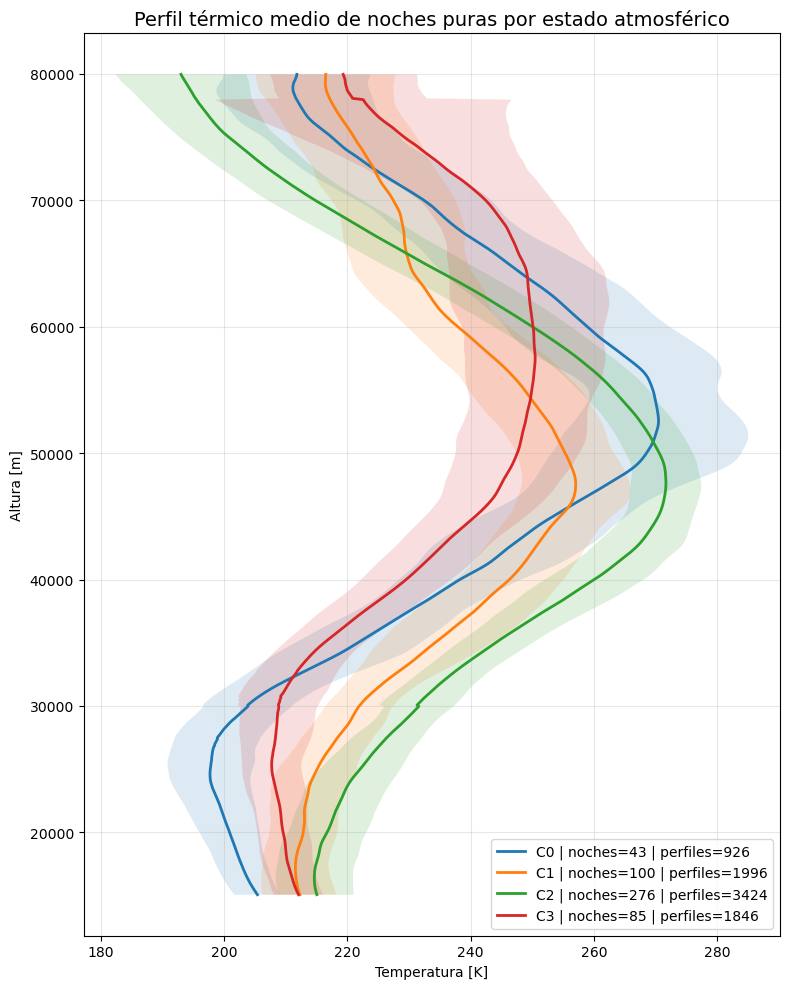

In [18]:
# Vamos a comparar los perfiles de las noches puras

import numpy as np
import matplotlib.pyplot as plt

cluster_col = "cluster_4"

df["fecha"] = pd.to_datetime(df["fecha"])
resumen_noches.index = pd.to_datetime(resumen_noches.index)

# Columnas de alturas
cols_alturas = [
    col for col in df.columns
    if str(col).isdigit()
]

alturas = np.array([int(col) for col in cols_alturas])

# Noches puras
noches_puras = resumen_noches[
    (resumen_noches["transiciones"] == 0) &
    (resumen_noches["max_pct"] == 1)
].copy()

fechas_puras = noches_puras.index

# Dataset sólo con perfiles pertenecientes a noches puras
df_puras = df[df["fecha"].isin(fechas_puras)].copy()

# Pasamos alturas a numérico por seguridad
df_puras[cols_alturas] = df_puras[cols_alturas].astype(float)

# Medias y desvios por cluster

stats_clusters = {}

for cluster in ["C0", "C1", "C2", "C3"]:
    
    fechas_cluster = noches_puras[
        noches_puras["cluster_dominante"] == cluster
    ].index
    
    datos_cluster = df_puras[
        df_puras["fecha"].isin(fechas_cluster)
    ][cols_alturas]
    
    media = datos_cluster.mean(axis=0).values
    desvio = datos_cluster.std(axis=0).values
    
    stats_clusters[cluster] = {
        "media": media,
        "desvio": desvio,
        "n_perfiles": len(datos_cluster),
        "n_noches": len(fechas_cluster)
    }

# Graficamos

fig, ax = plt.subplots(figsize=(8, 10))

for cluster, stats in stats_clusters.items():
    
    media = stats["media"]
    desvio = stats["desvio"]
    
    ax.plot(
        media,
        alturas,
        linewidth=2,
        label=f"{cluster} | noches={stats['n_noches']} | perfiles={stats['n_perfiles']}"
    )
    
    ax.fill_betweenx(
        alturas,
        media - desvio,
        media + desvio,
        alpha=0.15
    )

ax.set_title(
    "Perfil térmico medio de noches puras por estado atmosférico",
    fontsize=14
)

ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("Altura [m]")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



In [19]:
# noches totales
n_noches_total = len(resumen_noches)

# noches puras
n_noches_puras = len(noches_puras)

# porcentaje
pct_noches_puras = (
    n_noches_puras / n_noches_total * 100
)

print(f"Noches totales: {n_noches_total}")
print(f"Noches puras: {n_noches_puras}")
print(f"Porcentaje de noches puras: {pct_noches_puras:.2f}%")

Noches totales: 597
Noches puras: 504
Porcentaje de noches puras: 84.42%


In [28]:
# Vamos a armar una tabla con la ocurrencia de noches puras por mes

# Agregar mes a resumen nocturno desde df
mes_por_noche = (
    df.groupby("fecha")["mes"]
      .first()
)

noches_puras["mes"] = mes_por_noche

# Tabla: cantidad de noches puras por mes y cluster dominante
tabla_puras_mes = (
    noches_puras
    .groupby(["mes", "cluster_dominante"])
    .size()
    .unstack(fill_value=0)
)

# Asegurar meses 1 a 12 y clusters C0-C3
tabla_puras_mes = tabla_puras_mes.reindex(range(1, 13), fill_value=0)
tabla_puras_mes = tabla_puras_mes.reindex(columns=["C0", "C1", "C2", "C3"], fill_value=0)

tabla_puras_mes



cluster_dominante,C0,C1,C2,C3
mes,,,,
1,0,0,57,1
2,0,0,51,0
3,0,12,35,0
4,0,33,0,17
5,2,0,0,31
6,10,0,0,19
7,15,8,3,7
8,9,13,0,10
9,5,24,4,0


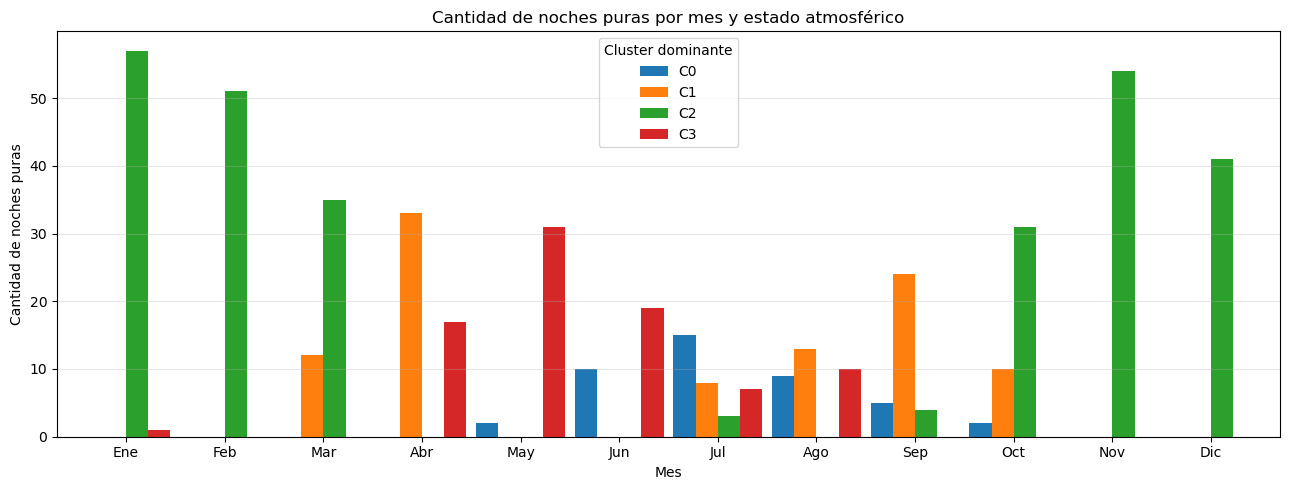

In [33]:
# Vamos a graficar la ocurrencia de noches puras por mes

meses = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

ax = tabla_puras_mes.plot(
    kind="bar",
    figsize=(13, 5),
    width=0.9
)

ax.set_title(
    "Cantidad de noches puras por mes y estado atmosférico"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de noches puras")

# reemplazar números por nombres
ax.set_xticklabels(meses, rotation=0)

ax.grid(axis="y", alpha=0.3)

plt.legend(title="Cluster dominante")

plt.tight_layout()
plt.show()

#### Conclusiones parciales sobre noches puras

Al considerar únicamente noches "puras" los perfiles medios de cada estado/cluster no difieren del calculado sobre el conjunto completo de perfiles.

Esto resultaría esperable, ya que las noches sin transiciones concentran 8192 de los 11041 perfiles originales, alrededor del 74%.

Esto confirma que los perfiles medios de cada cluster son representativos de determinadas perfiles de noches.

Adicinalmente, las noches "puras" son 504 del total de 597, alrededor de un 84%. 

Esto nos dice que la mayoría de las noches corresponden a un determinado tipo de perfil.


In [20]:
# Ahora que ya vimos las noches puras vamos a pasar a las noches mixtas

noches_mixtas = resumen_noches[
    ~resumen_noches.index.isin(noches_puras.index)
].copy()

print(f"Noches puras: {len(noches_puras)}")
print(f"Noches mixtas: {len(noches_mixtas)}")
print(f"% mixtas: {len(noches_mixtas) / len(resumen_noches) * 100:.2f}%")

Noches puras: 504
Noches mixtas: 93
% mixtas: 15.58%


In [22]:
# Vamos a analizar las noches misxtas

noches_mixtas["cluster_dominante"].value_counts().sort_index()
noches_mixtas["cluster_dominante"].value_counts(normalize=True).sort_index() * 100

cluster_dominante
C0    31.182796
C1    23.655914
C2    18.279570
C3    26.881720
Name: proportion, dtype: float64

In [24]:
# Vamos a ver cómo se combinan

cols_clusters = ["C0", "C1", "C2", "C3"]

def combinacion_clusters(row):
    presentes = [c for c in cols_clusters if row[c] > 0]
    return "-".join(presentes)

noches_mixtas["combinacion"] = noches_mixtas.apply(combinacion_clusters, axis=1)

noches_mixtas["combinacion"].value_counts()

combinacion
C0-C3       32
C1-C2       26
C0-C1       13
C1-C3       10
C0-C1-C3     8
C0-C2        3
C0-C1-C2     1
Name: count, dtype: int64

In [25]:
# Vamos a ver las noches mixtas más representativas

noches_mixtas.sort_values(
    ["entropia", "transiciones_norm"],
    ascending=False
).head(15)


,C0,C1,C2,C3,cluster_dominante,max_pct,entropia,transiciones,n_perfiles,transiciones_norm,combinacion
fecha,,,,,,,,,,,
2023-06-21,0.285714,0.285714,0.000000,0.428571,C3,0.428571,1.078992,3,7,0.500000,C0-C1-C3
2024-07-05,0.529412,0.235294,0.235294,0.000000,C0,0.529412,1.017603,2,17,0.125000,C0-C1-C2
2022-09-05,0.200000,0.550000,0.000000,0.250000,C1,0.550000,0.997272,2,20,0.105263,C0-C1-C3
2024-08-28,0.283333,0.550000,0.000000,0.166667,C1,0.550000,0.984757,2,60,0.033898,C0-C1-C3
2023-07-10,0.500000,0.392857,0.000000,0.107143,C0,0.500000,0.952937,5,28,0.185185,C0-C1-C3
2024-07-01,0.274194,0.112903,0.000000,0.612903,C3,0.612903,0.901098,6,62,0.098361,C0-C1-C3
2023-06-18,0.666667,0.148148,0.000000,0.185185,C0,0.666667,0.865501,2,27,0.076923,C0-C1-C3
2023-07-04,0.483333,0.483333,0.000000,0.033333,C0,0.483333,0.816187,2,60,0.033898,C0-C1-C3
2024-08-07,0.000000,0.500000,0.000000,0.500000,C1,0.500000,0.693147,1,2,1.000000,C1-C3


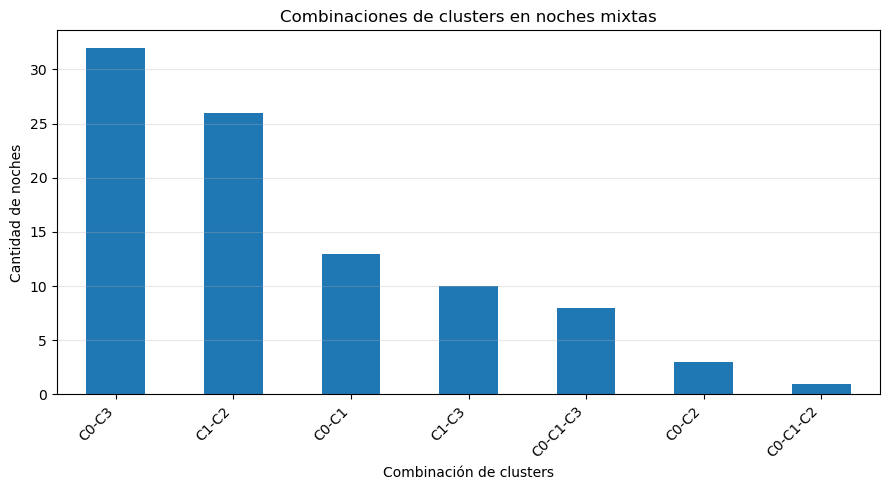

In [26]:
plt.figure(figsize=(9,5))

noches_mixtas["combinacion"].value_counts().plot(kind="bar")

plt.title("Combinaciones de clusters en noches mixtas")
plt.xlabel("Combinación de clusters")
plt.ylabel("Cantidad de noches")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Vamos a ver cómo se comportan estas combinaciones
# Cómo ocurren las transiciones

# ordenar por fecha y tiempo
df_ordenado = (
    df.sort_values(["fecha", "time"])
    .copy()
)

# lista de transiciones
transiciones = []

for fecha, grupo in df_ordenado.groupby("fecha"):
    
    secuencia = grupo[cluster_col].values
    
    for i in range(len(secuencia) - 1):
        
        origen = f"C{secuencia[i]}"
        destino = f"C{secuencia[i+1]}"
        
        transiciones.append((origen, destino))

# dataframe de transiciones
df_transiciones = pd.DataFrame(
    transiciones,
    columns=["origen", "destino"]
)

df_transiciones.head()

,origen,destino
0,C2,C2
1,C2,C2
2,C2,C2
3,C2,C2
4,C2,C2


In [35]:
matriz_transicion = pd.crosstab(
    df_transiciones["origen"],
    df_transiciones["destino"]
)

matriz_transicion

destino,C0,C1,C2,C3
origen,,,,
C0,1624,18,3,38
C1,14,2561,21,16
C2,3,31,3456,0
C3,36,10,0,2613


In [36]:
matriz_transicion_pct = (
    matriz_transicion.div(
        matriz_transicion.sum(axis=1),
        axis=0
    ) * 100
)

matriz_transicion_pct.round(2)

destino,C0,C1,C2,C3
origen,,,,
C0,96.49,1.07,0.18,2.26
C1,0.54,98.05,0.80,0.61
C2,0.09,0.89,99.03,0.00
C3,1.35,0.38,0.00,98.27


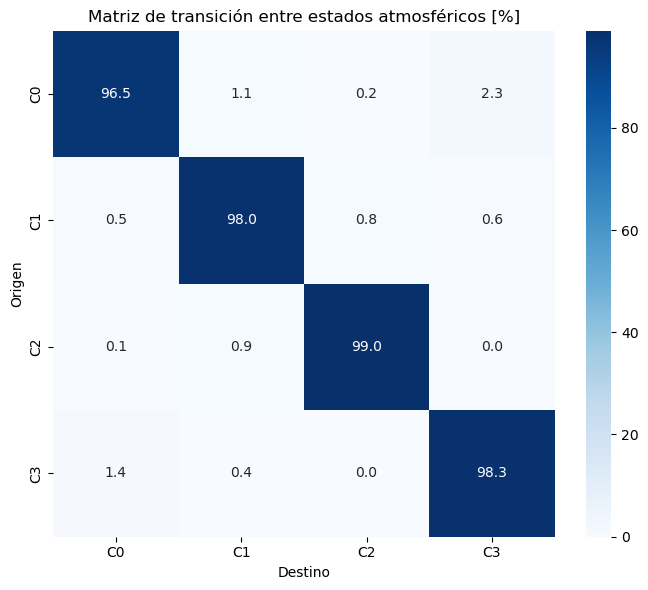

In [37]:
# Vamos a graficarlo

import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    matriz_transicion_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Matriz de transición entre estados atmosféricos [%]")

plt.xlabel("Destino")
plt.ylabel("Origen")

plt.tight_layout()
plt.show()

### Conclusines parciales sobre noches mixtas

La matriz de transición muestra que los estados atmosféricos tienden a mantenerse durante la noche. En todos los clusters, la probabilidad de que un perfil sea seguido por otro del mismo cluster supera el 96%. Esto significa que, una vez que una noche entra en un determinado estado, lo más habitual es que continúe en ese mismo estado durante la observación.

También se observa que las transiciones entre clusters no ocurren de cualquier manera. Algunos cambios aparecen con más frecuencia, como los intercambios entre C0 y C3, mientras que otros casi no aparecen, como las transiciones entre C0 y C2. Esto sugiere que algunos estados son más parecidos o cercanos entre sí, mientras que otros representan condiciones atmosféricas más diferentes.

En conjunto, la matriz de transición refuerza la interpretación estacional de los clusters. C2 aparece como un estado muy estable asociado principalmente al verano; C0 y C3 parecen representar dos estados invernales distintos, pero relativamente cercanos entre sí; y C1 queda como un estado intermedio, más frecuente en otoño y primavera, que puede actuar como transición entre los estados cálidos y fríos.


In [38]:
# Vamos a ver ejemplos concretos de noches mixtas

cols_clusters = ["C0", "C1", "C2", "C3"]

def combinacion_clusters(row):
    presentes = [c for c in cols_clusters if row[c] > 0]
    return "-".join(presentes)

noches_mixtas = resumen_noches[
    ~(
        (resumen_noches["transiciones"] == 0) &
        (resumen_noches["max_pct"] == 1)
    )
].copy()

noches_mixtas["combinacion"] = noches_mixtas.apply(
    combinacion_clusters,
    axis=1
)

noches_mixtas[[
    "cluster_dominante",
    "max_pct",
    "entropia",
    "transiciones",
    "transiciones_norm",
    "n_perfiles",
    "combinacion"
]].sort_values(
    ["combinacion", "n_perfiles"],
    ascending=[True, False]
).head(20)

,cluster_dominante,max_pct,entropia,transiciones,transiciones_norm,n_perfiles,combinacion
fecha,,,,,,,
2022-09-11,C0,0.596491,0.674409,4,0.071429,57,C0-C1
2023-09-03,C1,0.884615,0.357627,3,0.058824,52,C0-C1
2023-08-14,C1,0.656250,0.643492,1,0.032258,32,C0-C1
2022-09-24,C0,0.580645,0.680083,1,0.033333,31,C0-C1
2023-09-25,C0,0.956522,0.178845,1,0.045455,23,C0-C1
2023-09-12,C0,0.947368,0.206192,1,0.055556,19,C0-C1
2022-09-22,C0,0.777778,0.529706,1,0.058824,18,C0-C1
2023-08-02,C0,0.777778,0.529706,1,0.058824,18,C0-C1
2024-09-11,C1,0.866667,0.392674,3,0.214286,15,C0-C1


In [39]:
combinaciones_interes = ["C0-C3", "C1-C2", "C0-C1", "C1-C3"]

noches_representativas = (
    noches_mixtas[
        noches_mixtas["combinacion"].isin(combinaciones_interes)
    ]
    .sort_values("n_perfiles", ascending=False)
    .groupby("combinacion")
    .head(1)
)

noches_representativas

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia,transiciones,n_perfiles,transiciones_norm,combinacion
fecha,,,,,,,,,,,
2022-07-06,0.113924,0.000000,0.000000,0.886076,C3,0.886076,0.354642,1,79,0.012821,C0-C3
2024-07-18,0.000000,0.898305,0.101695,0.000000,C1,0.898305,0.328791,2,59,0.034483,C1-C2
2022-09-11,0.596491,0.403509,0.000000,0.000000,C0,0.596491,0.674409,4,57,0.071429,C0-C1
2023-04-19,0.000000,0.122449,0.000000,0.877551,C3,0.877551,0.371776,2,49,0.041667,C1-C3


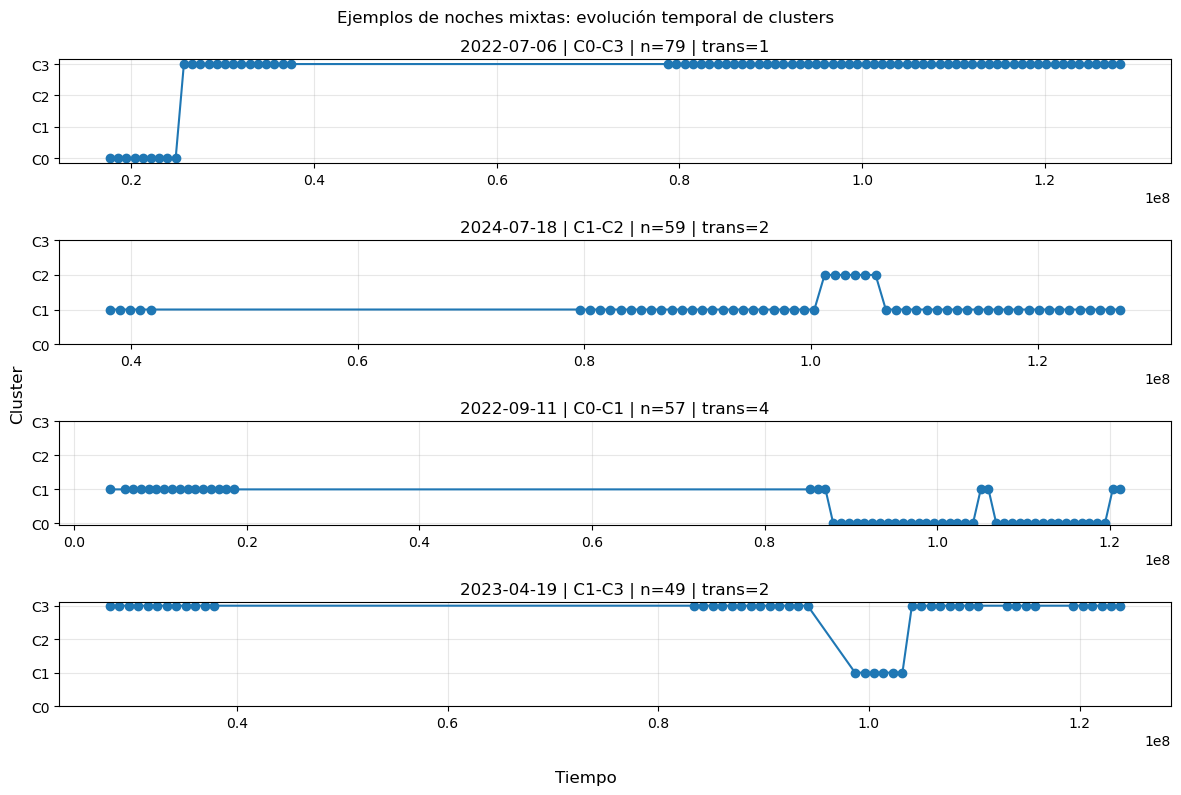

In [40]:
fig, axes = plt.subplots(
    nrows=len(noches_representativas),
    ncols=1,
    figsize=(12, 8),
    sharex=False
)

for ax, (fecha, row) in zip(axes, noches_representativas.iterrows()):

    noche = (
        df[df["fecha"] == fecha]
        .sort_values("time")
    )

    ax.plot(
        noche["time"],
        noche[cluster_col],
        marker="o",
        linewidth=1.5
    )

    ax.set_title(
        f"{fecha.date()} | {row['combinacion']} | "
        f"n={row['n_perfiles']} | trans={row['transiciones']}"
    )

    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["C0", "C1", "C2", "C3"])

    ax.grid(alpha=0.3)

fig.suptitle("Ejemplos de noches mixtas: evolución temporal de clusters")

fig.supxlabel("Tiempo")
fig.supylabel("Cluster")

plt.tight_layout()
plt.show()

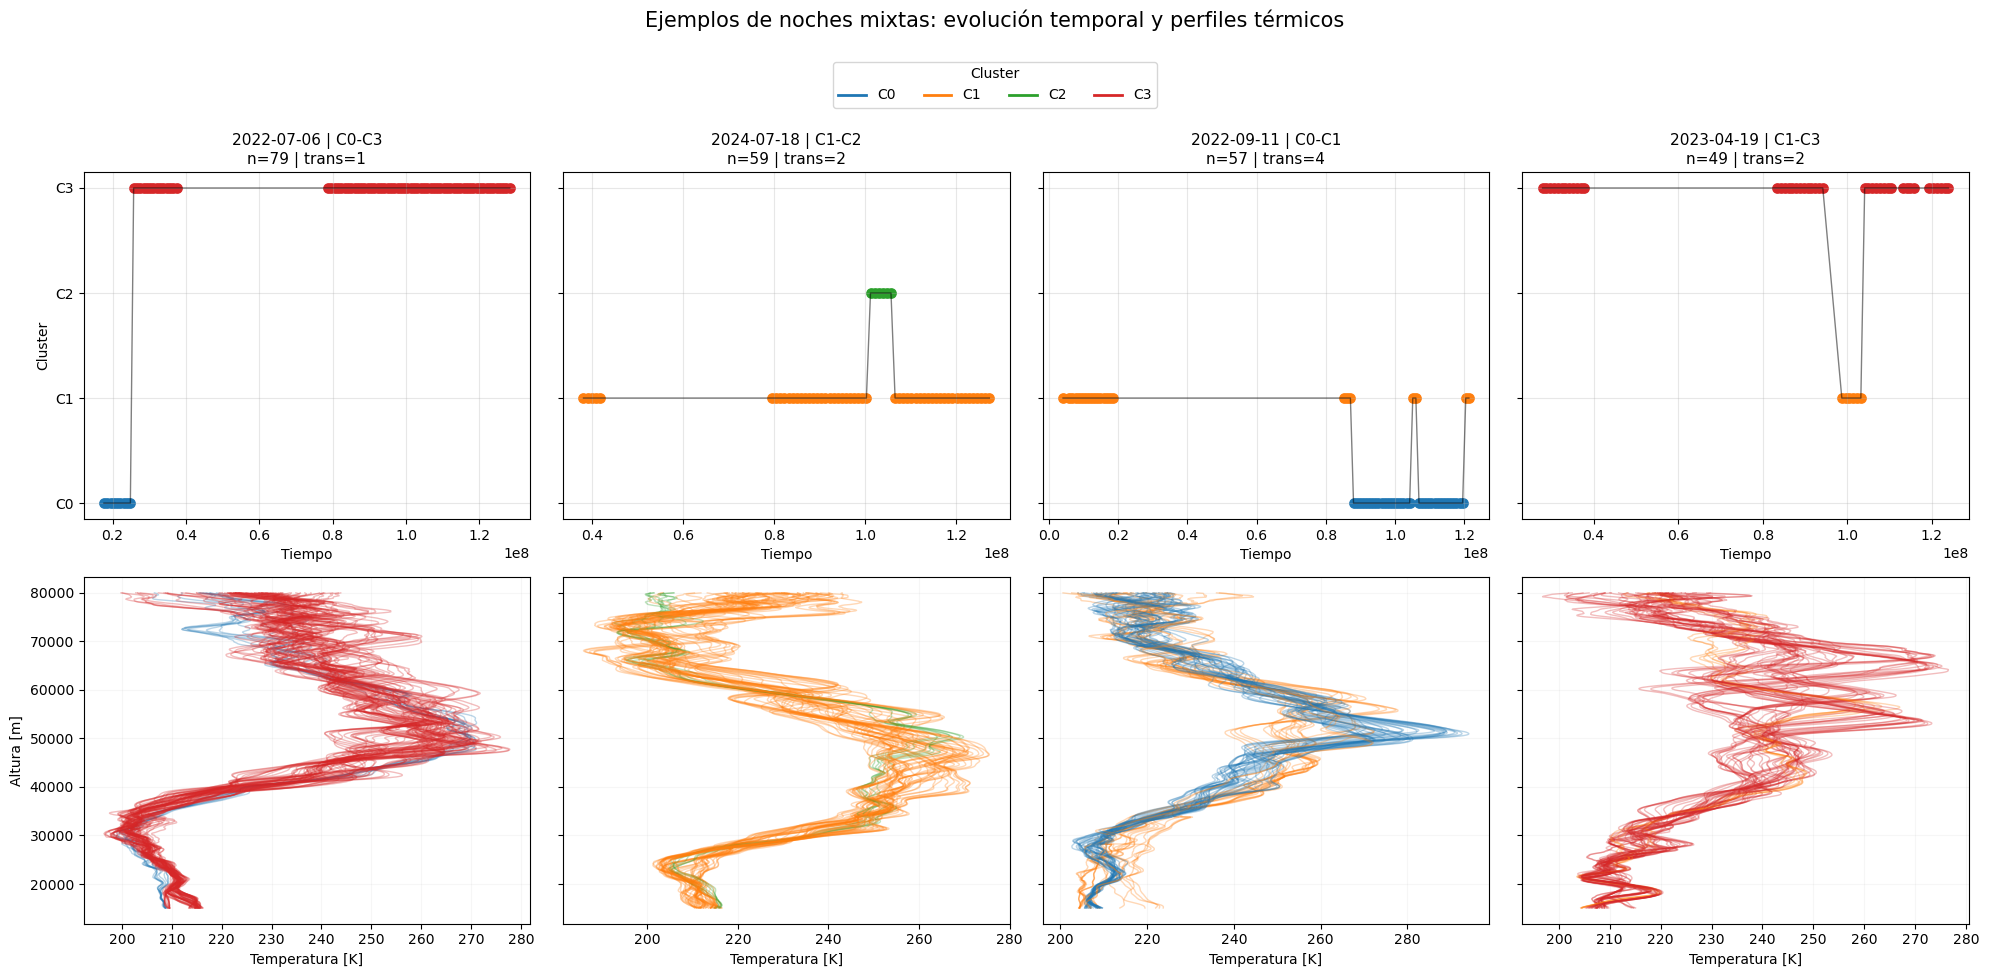

In [45]:
# Algo un poco más lindo

from matplotlib.lines import Line2D

# Clusters y colores
colores_clusters = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red"
}

labels_clusters = {
    0: "C0",
    1: "C1",
    2: "C2",
    3: "C3"
}

n_cols = len(noches_representativas)

fig, axes = plt.subplots(
    nrows=2,
    ncols=n_cols,
    figsize=(5 * n_cols, 9),
    sharey="row"
)

# Por si hay una sola columna
if n_cols == 1:
    axes = np.array(axes).reshape(2, 1)

for j, (fecha, row) in enumerate(noches_representativas.iterrows()):
    
    noche = (
        df[df["fecha"] == fecha]
        .sort_values("time")
        .copy()
    )
    
    # -------------------------
    # Fila superior: evolución temporal
    # -------------------------
    ax_top = axes[0, j]
    
    for c in sorted(noche[cluster_col].unique()):
        
        datos_c = noche[noche[cluster_col] == c]
        
        ax_top.scatter(
            datos_c["time"],
            datos_c[cluster_col],
            color=colores_clusters[c],
            label=labels_clusters[c],
            s=45
        )
    
    ax_top.plot(
        noche["time"],
        noche[cluster_col],
        color="black",
        linewidth=1,
        alpha=0.5
    )
    
    ax_top.set_title(
        f"{fecha.date()} | {row['combinacion']}\n"
        f"n={int(row['n_perfiles'])} | trans={int(row['transiciones'])}",
        fontsize=11
    )
    
    ax_top.set_yticks([0, 1, 2, 3])
    ax_top.set_yticklabels(["C0", "C1", "C2", "C3"])
    ax_top.set_xlabel("Tiempo")
    ax_top.grid(alpha=0.3)
    
    # -------------------------
    # Fila inferior: perfiles térmicos
    # -------------------------
    ax_bottom = axes[1, j]
    
    for _, perfil in noche.iterrows():
        
        c = int(perfil[cluster_col])
        
        ax_bottom.plot(
            perfil[cols_alturas].values,
            alturas,
            color=colores_clusters[c],
            alpha=0.3,
            linewidth=1
        )
    
    ax_bottom.set_xlabel("Temperatura [K]")
    ax_bottom.grid(alpha=0.1)

# Etiquetas generales
axes[0, 0].set_ylabel("Cluster")
axes[1, 0].set_ylabel("Altura [m]")

# Leyenda común
legend_elements = [
    Line2D(
        [0], [0],
        color=colores_clusters[c],
        lw=2,
        label=labels_clusters[c]
    )
    for c in [0, 1, 2, 3]
]

fig.legend(
    handles=legend_elements,
    title="Cluster",
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.03)
)

fig.suptitle(
    "Ejemplos de noches mixtas: evolución temporal y perfiles térmicos",
    fontsize=15,
    y=1.08
)

plt.tight_layout()
plt.show()
